In [ ]:
# Cell 1 — Load saved Phase 2 text-calorie dataset splits

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np

# Main Phase 2 directory
PHASE2_DIR = Path("/content/drive/MyDrive/Calorify/phase2_text_calorie")

# Important folders
DATA_DIR = PHASE2_DIR / "data"
CLEAN_DIR = DATA_DIR / "cleaned"
RESULTS_DIR = PHASE2_DIR / "results"
MODELS_DIR = PHASE2_DIR / "models"
LOGS_DIR = PHASE2_DIR / "logs"

# Create output folders if they do not exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

# Saved split paths from previous notebook
train_v2_path = CLEAN_DIR / "cleaned_text_calorie_train_v2.csv"
val_v2_path = CLEAN_DIR / "cleaned_text_calorie_val_v2.csv"
test_v2_path = CLEAN_DIR / "cleaned_text_calorie_test_v2.csv"

# Load splits
train_v2_df = pd.read_csv(train_v2_path)
val_v2_df = pd.read_csv(val_v2_path)
test_v2_df = pd.read_csv(test_v2_path)

print("Phase 2 text-calorie splits loaded successfully.")

print("\nTrain shape:")
print(train_v2_df.shape)

print("\nValidation shape:")
print(val_v2_df.shape)

print("\nTest shape:")
print(test_v2_df.shape)

print("\nColumns:")
print(train_v2_df.columns.tolist())

print("\nTrain class distribution:")
print(train_v2_df["food_class"].value_counts())

print("\nValidation class distribution:")
print(val_v2_df["food_class"].value_counts())

print("\nTest class distribution:")
print(test_v2_df["food_class"].value_counts())

print("\nMissing values check:")
print("Train missing:", train_v2_df.isna().sum().sum())
print("Validation missing:", val_v2_df.isna().sum().sum())
print("Test missing:", test_v2_df.isna().sum().sum())

# Leakage checks
train_urls = set(train_v2_df["source_url"])
val_urls = set(val_v2_df["source_url"])
test_urls = set(test_v2_df["source_url"])

print("\nURL overlap checks:")
print("Train-Val overlap:", len(train_urls.intersection(val_urls)))
print("Train-Test overlap:", len(train_urls.intersection(test_urls)))
print("Val-Test overlap:", len(val_urls.intersection(test_urls)))

train_ids = set(train_v2_df["record_id"])
val_ids = set(val_v2_df["record_id"])
test_ids = set(test_v2_df["record_id"])

print("\nRecord ID overlap checks:")
print("Train-Val overlap:", len(train_ids.intersection(val_ids)))
print("Train-Test overlap:", len(train_ids.intersection(test_ids)))
print("Val-Test overlap:", len(val_ids.intersection(test_ids)))

print("\nCalories summary in train:")
print(train_v2_df["calories"].describe())

Mounted at /content/drive
Phase 2 text-calorie splits loaded successfully.

Train shape:
(310, 15)

Validation shape:
(66, 15)

Test shape:
(67, 15)

Columns:
['record_id', 'source_site', 'food_class', 'query', 'recipe_name', 'ingredients_text', 'clean_recipe_name', 'clean_ingredients_text', 'input_text', 'calories', 'protein', 'fat', 'carbs', 'source_url', 'scraped_at']

Train class distribution:
food_class
pizza       34
rice        33
burger      33
sandwich    32
pasta       31
salad       31
fries       31
chicken     29
sushi       29
steak       27
Name: count, dtype: int64

Validation class distribution:
food_class
pasta       7
rice        7
salad       7
burger      7
pizza       7
sandwich    7
fries       6
steak       6
sushi       6
chicken     6
Name: count, dtype: int64

Test class distribution:
food_class
pizza       7
rice        7
sandwich    7
salad       7
fries       7
pasta       7
burger      7
sushi       6
chicken     6
steak       6
Name: count, dtype: int64


In [ ]:
# Cell 2 — Class average baseline for calorie estimation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate average calories per food class from training data only
class_average_calories = (
    train_v2_df
    .groupby("food_class")["calories"]
    .mean()
    .to_dict()
)

global_train_average = train_v2_df["calories"].mean()

print("Class average calories from training data:")
for food_class, avg_calories in class_average_calories.items():
    print(food_class, ":", round(avg_calories, 2))

print("\nGlobal train average calories:")
print(round(global_train_average, 2))

# Predict validation calories using only food_class average
baseline_val_df = val_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "source_url"
]].copy()

baseline_val_df["predicted_calories"] = baseline_val_df["food_class"].map(class_average_calories)

# Fallback in case any class is missing, though it should not happen
baseline_val_df["predicted_calories"] = baseline_val_df["predicted_calories"].fillna(global_train_average)

baseline_val_df["absolute_error"] = np.abs(
    baseline_val_df["calories"] - baseline_val_df["predicted_calories"]
)

# Evaluation metrics
y_val_true = baseline_val_df["calories"].astype(float)
y_val_pred = baseline_val_df["predicted_calories"].astype(float)

baseline_val_mae = mean_absolute_error(y_val_true, y_val_pred)
baseline_val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
baseline_val_r2 = r2_score(y_val_true, y_val_pred)

print("\nClass Average Baseline validation results:")
print("Validation MAE:", baseline_val_mae)
print("Validation RMSE:", baseline_val_rmse)
print("Validation R2:", baseline_val_r2)

print("\nValidation prediction sample:")
display(baseline_val_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "calories",
    "predicted_calories",
    "absolute_error"
]].head(15))

print("\nValidation error summary:")
display(baseline_val_df["absolute_error"].describe())

print("\nValidation MAE by food class:")
baseline_mae_by_class_df = (
    baseline_val_df
    .groupby("food_class")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(baseline_mae_by_class_df)

# Save baseline outputs
class_average_baseline_path = RESULTS_DIR / "class_average_baseline_validation_predictions.csv"
class_average_mapping_path = RESULTS_DIR / "class_average_calories_train_mapping.csv"

baseline_val_df.to_csv(class_average_baseline_path, index=False)

class_average_mapping_df = pd.DataFrame({
    "food_class": list(class_average_calories.keys()),
    "train_average_calories": list(class_average_calories.values())
}).sort_values("food_class").reset_index(drop=True)

class_average_mapping_df.to_csv(class_average_mapping_path, index=False)

print("\nBaseline validation predictions saved to:")
print(class_average_baseline_path)

print("\nClass average mapping saved to:")
print(class_average_mapping_path)

Class average calories from training data:
burger : 559.85
chicken : 406.52
fries : 402.23
pasta : 611.13
pizza : 406.65
rice : 446.36
salad : 411.84
sandwich : 527.56
steak : 472.33
sushi : 300.83

Global train average calories:
456.0

Class Average Baseline validation results:
Validation MAE: 179.8768935206791
Validation RMSE: 233.94469001060295
Validation R2: 0.024713237680840106

Validation prediction sample:


,record_id,food_class,recipe_name,calories,predicted_calories,absolute_error
0,TXT_00003,pasta,15-minute chicken pasta,531.0,611.129032,80.129032
1,TXT_00093,rice,Chorizo egg-fried rice,325.0,446.363636,121.363636
2,TXT_00256,salad,Pomegranate salad,243.0,411.838710,168.838710
3,TXT_00431,sushi,Uramaki 裏巻き,480.0,300.827586,179.172414
4,TXT_00324,steak,Steak & aubergine salad,455.0,472.333333,17.333333
5,TXT_00179,fries,Italian pork patties with potato wedges,503.0,402.225806,100.774194
6,TXT_00119,chicken,Crunchy beetroot slaw with grilled chicken,299.0,406.517241,107.517241
7,TXT_00089,fries,Chimichurri steaks with sweet potato fries & o...,432.0,402.225806,29.774194
8,TXT_00156,sandwich,Green club sandwich,583.0,527.562500,55.437500
9,TXT_00377,fries,Waste-nothing loaded potato wedges,427.0,402.225806,24.774194



Validation error summary:


,absolute_error
count,66.000000
mean,179.876894
std,150.727048
min,2.333333
25%,62.610963
50%,153.655172
75%,268.732448
max,709.437500



Validation MAE by food class:


,count,mean,median,max
food_class,,,,
sandwich,7,292.508929,285.562500,709.437500
steak,6,282.611111,220.833333,628.666667
burger,7,249.978355,311.848485,384.848485
pizza,7,177.008403,170.352941,286.352941
pasta,7,167.838710,203.129032,276.870968
sushi,6,160.057471,149.500000,320.172414
salad,7,129.170507,128.838710,221.161290
chicken,6,127.827586,132.000000,300.482759
rice,7,115.623377,59.363636,361.636364



Baseline validation predictions saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/class_average_baseline_validation_predictions.csv

Class average mapping saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/class_average_calories_train_mapping.csv


In [ ]:
# Cell 3 — TF-IDF + Ridge Regression calorie estimation model

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Prepare train and validation data
X_train = train_v2_df["input_text"].astype(str)
y_train = train_v2_df["calories"].astype(float)

X_val = val_v2_df["input_text"].astype(str)
y_val = val_v2_df["calories"].astype(float)

print("Training records:", len(X_train))
print("Validation records:", len(X_val))

# Build TF-IDF + Ridge regression pipeline
tfidf_ridge_calorie_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("regressor", Ridge(
        alpha=10.0,
        random_state=42
    ))
])

# Train model
tfidf_ridge_calorie_model.fit(X_train, y_train)

# Predict validation calories
ridge_val_predictions = tfidf_ridge_calorie_model.predict(X_val)

# Avoid negative calorie predictions
ridge_val_predictions = np.maximum(ridge_val_predictions, 0)

# Evaluation metrics
ridge_val_mae = mean_absolute_error(y_val, ridge_val_predictions)
ridge_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_predictions))
ridge_val_r2 = r2_score(y_val, ridge_val_predictions)

print("\nTF-IDF + Ridge Regression validation results:")
print("Validation MAE:", ridge_val_mae)
print("Validation RMSE:", ridge_val_rmse)
print("Validation R2:", ridge_val_r2)

print("\nComparison against Class Average Baseline:")
print("Baseline MAE:", baseline_val_mae)
print("Ridge MAE:", ridge_val_mae)
print("MAE improvement:", baseline_val_mae - ridge_val_mae)

# Create validation prediction dataframe
ridge_val_results_df = val_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "protein",
    "fat",
    "carbs",
    "source_url"
]].copy()

ridge_val_results_df["predicted_calories"] = ridge_val_predictions
ridge_val_results_df["absolute_error"] = np.abs(
    ridge_val_results_df["calories"] - ridge_val_results_df["predicted_calories"]
)

print("\nValidation prediction sample:")
display(ridge_val_results_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "calories",
    "predicted_calories",
    "absolute_error"
]].head(15))

print("\nValidation error summary:")
display(ridge_val_results_df["absolute_error"].describe())

print("\nValidation MAE by food class:")
ridge_mae_by_class_df = (
    ridge_val_results_df
    .groupby("food_class")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(ridge_mae_by_class_df)

# Save model and outputs
ridge_val_results_path = RESULTS_DIR / "tfidf_ridge_validation_predictions.csv"
ridge_model_path = MODELS_DIR / "tfidf_ridge_calorie_model.joblib"

ridge_val_results_df.to_csv(ridge_val_results_path, index=False)
joblib.dump(tfidf_ridge_calorie_model, ridge_model_path)

ridge_summary_df = pd.DataFrame([{
    "model_name": "TF-IDF + Ridge Regression",
    "validation_mae": ridge_val_mae,
    "validation_rmse": ridge_val_rmse,
    "validation_r2": ridge_val_r2,
    "baseline_mae": baseline_val_mae,
    "mae_improvement_over_baseline": baseline_val_mae - ridge_val_mae
}])

ridge_summary_path = RESULTS_DIR / "tfidf_ridge_validation_summary.csv"
ridge_summary_df.to_csv(ridge_summary_path, index=False)

print("\nRidge validation predictions saved to:")
print(ridge_val_results_path)

print("\nRidge model saved to:")
print(ridge_model_path)

print("\nRidge validation summary saved to:")
print(ridge_summary_path)

Training records: 310
Validation records: 66

TF-IDF + Ridge Regression validation results:
Validation MAE: 174.94168273061783
Validation RMSE: 224.41954376886815
Validation R2: 0.10251480027509885

Comparison against Class Average Baseline:
Baseline MAE: 179.8768935206791
Ridge MAE: 174.94168273061783
MAE improvement: 4.935210790061262

Validation prediction sample:


,record_id,food_class,recipe_name,calories,predicted_calories,absolute_error
0,TXT_00003,pasta,15-minute chicken pasta,531.0,507.052236,23.947764
1,TXT_00093,rice,Chorizo egg-fried rice,325.0,456.649665,131.649665
2,TXT_00256,salad,Pomegranate salad,243.0,449.741717,206.741717
3,TXT_00431,sushi,Uramaki 裏巻き,480.0,360.306162,119.693838
4,TXT_00324,steak,Steak & aubergine salad,455.0,470.480042,15.480042
5,TXT_00179,fries,Italian pork patties with potato wedges,503.0,431.598024,71.401976
6,TXT_00119,chicken,Crunchy beetroot slaw with grilled chicken,299.0,457.003656,158.003656
7,TXT_00089,fries,Chimichurri steaks with sweet potato fries & o...,432.0,438.154841,6.154841
8,TXT_00156,sandwich,Green club sandwich,583.0,470.027229,112.972771
9,TXT_00377,fries,Waste-nothing loaded potato wedges,427.0,490.130129,63.130129



Validation error summary:


,absolute_error
count,66.000000
mean,174.941683
std,141.645798
min,2.647316
25%,70.446380
50%,156.421976
75%,230.031631
max,741.124539



Validation MAE by food class:


,count,mean,median,max
food_class,,,,
sandwich,7,271.714105,200.658802,741.124539
steak,6,260.822479,176.330612,616.756097
burger,7,242.354509,242.372915,301.374573
pasta,7,185.617065,162.428629,372.267919
salad,7,155.948811,165.390762,206.741717
pizza,7,154.340946,137.292785,248.149858
chicken,6,129.883402,116.776027,256.180691
sushi,6,128.338693,121.548339,226.660814
rice,7,114.676545,55.190140,373.731797



Ridge validation predictions saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/tfidf_ridge_validation_predictions.csv

Ridge model saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/models/tfidf_ridge_calorie_model.joblib

Ridge validation summary saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/tfidf_ridge_validation_summary.csv


In [ ]:
# Cell 4 — Tune TF-IDF + Ridge Regression

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

X_train = train_v2_df["input_text"].astype(str)
y_train = train_v2_df["calories"].astype(float)

X_val = val_v2_df["input_text"].astype(str)
y_val = val_v2_df["calories"].astype(float)

ridge_experiments = []

alpha_values = [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
max_features_values = [1000, 3000, 5000, 8000]
ngram_ranges = [(1, 1), (1, 2)]

best_ridge_model = None
best_ridge_predictions = None
best_ridge_config = None
best_ridge_mae = float("inf")

for alpha in alpha_values:
    for max_features in max_features_values:
        for ngram_range in ngram_ranges:

            model = Pipeline([
                ("tfidf", TfidfVectorizer(
                    max_features=max_features,
                    ngram_range=ngram_range,
                    min_df=2,
                    max_df=0.95,
                    sublinear_tf=True
                )),
                ("regressor", Ridge(
                    alpha=alpha,
                    random_state=42
                ))
            ])

            model.fit(X_train, y_train)

            predictions = model.predict(X_val)
            predictions = np.maximum(predictions, 0)

            mae = mean_absolute_error(y_val, predictions)
            rmse = np.sqrt(mean_squared_error(y_val, predictions))
            r2 = r2_score(y_val, predictions)

            experiment_result = {
                "model_name": "TF-IDF + Ridge Tuned",
                "alpha": alpha,
                "max_features": max_features,
                "ngram_range": str(ngram_range),
                "validation_mae": mae,
                "validation_rmse": rmse,
                "validation_r2": r2,
                "baseline_mae": baseline_val_mae,
                "mae_improvement_over_baseline": baseline_val_mae - mae
            }

            ridge_experiments.append(experiment_result)

            if mae < best_ridge_mae:
                best_ridge_mae = mae
                best_ridge_model = model
                best_ridge_predictions = predictions
                best_ridge_config = experiment_result

ridge_tuning_results_df = pd.DataFrame(ridge_experiments).sort_values(
    "validation_mae",
    ascending=True
).reset_index(drop=True)

print("Ridge tuning finished.")

print("\nTop 10 Ridge configurations:")
display(ridge_tuning_results_df.head(10))

print("\nBest Ridge configuration:")
for key, value in best_ridge_config.items():
    print(key, ":", value)

# Build validation prediction dataframe for best tuned model
best_ridge_val_results_df = val_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "protein",
    "fat",
    "carbs",
    "source_url"
]].copy()

best_ridge_val_results_df["predicted_calories"] = best_ridge_predictions
best_ridge_val_results_df["absolute_error"] = np.abs(
    best_ridge_val_results_df["calories"] - best_ridge_val_results_df["predicted_calories"]
)

print("\nBest tuned Ridge validation error summary:")
display(best_ridge_val_results_df["absolute_error"].describe())

print("\nBest tuned Ridge MAE by food class:")
best_ridge_mae_by_class_df = (
    best_ridge_val_results_df
    .groupby("food_class")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(best_ridge_mae_by_class_df)

print("\nComparison:")
print("Class Average Baseline MAE:", baseline_val_mae)
print("Original Ridge MAE:", ridge_val_mae)
print("Best Tuned Ridge MAE:", best_ridge_config["validation_mae"])
print("Best Tuned Ridge improvement over baseline:", best_ridge_config["mae_improvement_over_baseline"])

# Save tuned Ridge outputs
ridge_tuning_results_path = RESULTS_DIR / "tfidf_ridge_tuning_results.csv"
best_ridge_val_predictions_path = RESULTS_DIR / "tfidf_ridge_best_validation_predictions.csv"
best_ridge_model_path = MODELS_DIR / "tfidf_ridge_best_calorie_model.joblib"

ridge_tuning_results_df.to_csv(ridge_tuning_results_path, index=False)
best_ridge_val_results_df.to_csv(best_ridge_val_predictions_path, index=False)
joblib.dump(best_ridge_model, best_ridge_model_path)

print("\nRidge tuning results saved to:")
print(ridge_tuning_results_path)

print("\nBest Ridge validation predictions saved to:")
print(best_ridge_val_predictions_path)

print("\nBest Ridge model saved to:")
print(best_ridge_model_path)

Ridge tuning finished.

Top 10 Ridge configurations:


,model_name,alpha,max_features,ngram_range,validation_mae,validation_rmse,validation_r2,baseline_mae,mae_improvement_over_baseline
0,TF-IDF + Ridge Tuned,0.1,1000,"(1, 2)",150.198049,191.376665,0.347345,179.876894,29.678844
1,TF-IDF + Ridge Tuned,0.1,3000,"(1, 2)",162.053464,199.840411,0.288340,179.876894,17.823429
2,TF-IDF + Ridge Tuned,0.1,8000,"(1, 2)",162.053464,199.840411,0.288340,179.876894,17.823429
3,TF-IDF + Ridge Tuned,0.1,5000,"(1, 2)",162.053464,199.840411,0.288340,179.876894,17.823429
4,TF-IDF + Ridge Tuned,1.0,1000,"(1, 2)",163.320871,200.692035,0.282262,179.876894,16.556022
5,TF-IDF + Ridge Tuned,1.0,5000,"(1, 2)",167.101274,206.400104,0.240853,179.876894,12.775620
6,TF-IDF + Ridge Tuned,1.0,3000,"(1, 2)",167.101274,206.400104,0.240853,179.876894,12.775620
7,TF-IDF + Ridge Tuned,1.0,8000,"(1, 2)",167.101274,206.400104,0.240853,179.876894,12.775620
8,TF-IDF + Ridge Tuned,3.0,1000,"(1, 2)",168.372754,209.509650,0.217807,179.876894,11.504140
9,TF-IDF + Ridge Tuned,3.0,5000,"(1, 2)",170.332502,213.676696,0.186383,179.876894,9.544391



Best Ridge configuration:
model_name : TF-IDF + Ridge Tuned
alpha : 0.1
max_features : 1000
ngram_range : (1, 2)
validation_mae : 150.19804948034061
validation_rmse : 191.37666482377404
validation_r2 : 0.3473446406354038
baseline_mae : 179.8768935206791
mae_improvement_over_baseline : 29.678844040338475

Best tuned Ridge validation error summary:


,absolute_error
count,66.000000
mean,150.198049
std,119.507185
min,7.196584
25%,72.088962
50%,111.189958
75%,203.906447
max,544.852216



Best tuned Ridge MAE by food class:


,count,mean,median,max
food_class,,,,
sandwich,7,217.825959,194.969151,544.852216
steak,6,203.685930,196.719632,403.006611
pizza,7,193.411810,87.534374,398.149661
burger,7,181.426575,133.717139,332.356062
sushi,6,137.802357,137.233707,310.010959
rice,7,133.097241,59.470018,516.671370
pasta,7,131.329545,154.586872,205.452778
chicken,6,117.433594,96.225721,254.687373
fries,6,91.223440,102.618527,156.751856



Comparison:
Class Average Baseline MAE: 179.8768935206791
Original Ridge MAE: 174.94168273061783
Best Tuned Ridge MAE: 150.19804948034061
Best Tuned Ridge improvement over baseline: 29.678844040338475

Ridge tuning results saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/tfidf_ridge_tuning_results.csv

Best Ridge validation predictions saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/tfidf_ridge_best_validation_predictions.csv

Best Ridge model saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/models/tfidf_ridge_best_calorie_model.joblib


In [ ]:
# Cell 5 — Neural text regression model: Embedding + GlobalAveragePooling

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)

# Prepare text and target data
X_train_text = train_v2_df["input_text"].astype(str).values
X_val_text = val_v2_df["input_text"].astype(str).values

y_train_calories = train_v2_df["calories"].astype(float).values
y_val_calories = val_v2_df["calories"].astype(float).values

# Scale calories for more stable neural network training
CALORIE_SCALE = 1000.0
y_train_scaled = y_train_calories / CALORIE_SCALE
y_val_scaled = y_val_calories / CALORIE_SCALE

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))

print("\nTrain calories summary:")
print(pd.Series(y_train_calories).describe())

print("\nValidation calories summary:")
print(pd.Series(y_val_calories).describe())

# Text vectorization layer
MAX_TOKENS = 10000
SEQUENCE_LENGTH = 100

text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation"
)

# Important: adapt only on training text to avoid data leakage
text_vectorizer.adapt(X_train_text)

vocab_size = len(text_vectorizer.get_vocabulary())

print("\nVocabulary size:", vocab_size)
print("Sequence length:", SEQUENCE_LENGTH)

# Build neural regression model
text_input = layers.Input(shape=(1,), dtype=tf.string, name="input_text")

x = text_vectorizer(text_input)
x = layers.Embedding(
    input_dim=vocab_size,
    output_dim=64,
    name="text_embedding"
)(x)

x = layers.GlobalAveragePooling1D(name="global_average_pooling")(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)

# Linear regression output on scaled calories
output = layers.Dense(1, activation="linear", name="scaled_calorie_output")(x)

embedding_gap_model = models.Model(
    inputs=text_input,
    outputs=output,
    name="embedding_gap_calorie_regression"
)

embedding_gap_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

embedding_gap_model.summary()

# Callbacks
embedding_gap_model_path = MODELS_DIR / "embedding_gap_calorie_model.keras"

model_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        filepath=str(embedding_gap_model_path),
        monitor="val_loss",
        save_best_only=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5
    )
]

# Train model
history_embedding_gap = embedding_gap_model.fit(
    X_train_text,
    y_train_scaled,
    validation_data=(X_val_text, y_val_scaled),
    epochs=150,
    batch_size=16,
    callbacks=model_callbacks,
    verbose=1
)

# Predict validation calories
embedding_gap_val_pred_scaled = embedding_gap_model.predict(X_val_text).flatten()
embedding_gap_val_predictions = embedding_gap_val_pred_scaled * CALORIE_SCALE

# Avoid negative predictions
embedding_gap_val_predictions = np.maximum(embedding_gap_val_predictions, 0)

# Evaluation in kcal
embedding_gap_val_mae = mean_absolute_error(y_val_calories, embedding_gap_val_predictions)
embedding_gap_val_rmse = np.sqrt(mean_squared_error(y_val_calories, embedding_gap_val_predictions))
embedding_gap_val_r2 = r2_score(y_val_calories, embedding_gap_val_predictions)

print("\nEmbedding + GlobalAveragePooling validation results:")
print("Validation MAE:", embedding_gap_val_mae)
print("Validation RMSE:", embedding_gap_val_rmse)
print("Validation R2:", embedding_gap_val_r2)

print("\nComparison:")
print("Class Average Baseline MAE:", baseline_val_mae)
print("Best Tuned Ridge MAE:", best_ridge_config["validation_mae"])
print("Embedding + GAP MAE:", embedding_gap_val_mae)
print("Improvement over baseline:", baseline_val_mae - embedding_gap_val_mae)
print("Improvement over best Ridge:", best_ridge_config["validation_mae"] - embedding_gap_val_mae)

# Build validation results dataframe
embedding_gap_val_results_df = val_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "protein",
    "fat",
    "carbs",
    "source_url"
]].copy()

embedding_gap_val_results_df["predicted_calories"] = embedding_gap_val_predictions
embedding_gap_val_results_df["absolute_error"] = np.abs(
    embedding_gap_val_results_df["calories"] - embedding_gap_val_results_df["predicted_calories"]
)

print("\nValidation prediction sample:")
display(embedding_gap_val_results_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "calories",
    "predicted_calories",
    "absolute_error"
]].head(15))

print("\nValidation error summary:")
display(embedding_gap_val_results_df["absolute_error"].describe())

print("\nValidation MAE by food class:")
embedding_gap_mae_by_class_df = (
    embedding_gap_val_results_df
    .groupby("food_class")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(embedding_gap_mae_by_class_df)

# Save history and results
embedding_gap_history_df = pd.DataFrame(history_embedding_gap.history)
embedding_gap_history_path = RESULTS_DIR / "embedding_gap_training_history.csv"
embedding_gap_val_results_path = RESULTS_DIR / "embedding_gap_validation_predictions.csv"

embedding_gap_history_df.to_csv(embedding_gap_history_path, index=False)
embedding_gap_val_results_df.to_csv(embedding_gap_val_results_path, index=False)

embedding_gap_summary_df = pd.DataFrame([{
    "model_name": "Embedding + GlobalAveragePooling Regression",
    "validation_mae": embedding_gap_val_mae,
    "validation_rmse": embedding_gap_val_rmse,
    "validation_r2": embedding_gap_val_r2,
    "baseline_mae": baseline_val_mae,
    "best_tuned_ridge_mae": best_ridge_config["validation_mae"],
    "mae_improvement_over_baseline": baseline_val_mae - embedding_gap_val_mae,
    "mae_improvement_over_best_ridge": best_ridge_config["validation_mae"] - embedding_gap_val_mae,
    "vocab_size": vocab_size,
    "sequence_length": SEQUENCE_LENGTH,
    "calorie_scale": CALORIE_SCALE
}])

embedding_gap_summary_path = RESULTS_DIR / "embedding_gap_validation_summary.csv"
embedding_gap_summary_df.to_csv(embedding_gap_summary_path, index=False)

print("\nEmbedding + GAP model saved to:")
print(embedding_gap_model_path)

print("\nEmbedding + GAP training history saved to:")
print(embedding_gap_history_path)

print("\nEmbedding + GAP validation predictions saved to:")
print(embedding_gap_val_results_path)

print("\nEmbedding + GAP validation summary saved to:")
print(embedding_gap_summary_path)

Training samples: 310
Validation samples: 66

Train calories summary:
count     310.000000
mean      456.000000
std       220.377082
min        49.000000
25%       303.000000
50%       416.500000
75%       572.250000
max      1394.000000
dtype: float64

Validation calories summary:
count      66.000000
mean      483.333333
std       238.705440
min       150.000000
25%       287.000000
50%       435.500000
75%       630.000000
max      1237.000000
dtype: float64

Vocabulary size: 1655
Sequence length: 100


Model: "embedding_gap_calorie_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_text (InputLayer)         │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_embedding (Embedding)      │ (None, 100, 64)        │       105,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaled_calorie_output (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,561 (478.75 KB)

 Trainable params: 122,561 (478.75 KB)

...


Validation error summary:


,absolute_error
count,66.000000
mean,164.099538
std,119.460863
min,1.878326
25%,65.341896
50%,131.266632
75%,234.712280
max,476.610870



Validation MAE by food class:


,count,mean,median,max
food_class,,,,
pasta,7,222.542306,218.547974,417.980103
burger,7,219.274122,218.834473,357.481415
pizza,7,214.579747,206.440369,349.748230
sandwich,7,204.076146,175.436890,455.878540
steak,6,150.474477,125.801453,349.198120
rice,7,149.108063,65.475037,476.610870
salad,7,133.337010,115.569794,240.822906
sushi,6,128.799316,129.475571,235.522034
chicken,6,118.216944,85.936005,292.771545



Embedding + GAP model saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/models/embedding_gap_calorie_model.keras

Embedding + GAP training history saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/embedding_gap_training_history.csv

Embedding + GAP validation predictions saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/embedding_gap_validation_predictions.csv

Embedding + GAP validation summary saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/embedding_gap_validation_summary.csv


In [ ]:
# Cell 6 — LSTM calorie regression model

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)

# Prepare text and target data
X_train_text = train_v2_df["input_text"].astype(str).values
X_val_text = val_v2_df["input_text"].astype(str).values

y_train_calories = train_v2_df["calories"].astype(float).values
y_val_calories = val_v2_df["calories"].astype(float).values

# Scale calories for stable neural training
CALORIE_SCALE = 1000.0
y_train_scaled = y_train_calories / CALORIE_SCALE
y_val_scaled = y_val_calories / CALORIE_SCALE

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))

# Text vectorization layer
MAX_TOKENS = 10000
SEQUENCE_LENGTH = 100

lstm_text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation"
)

# Important: adapt only on training text
lstm_text_vectorizer.adapt(X_train_text)

lstm_vocab_size = len(lstm_text_vectorizer.get_vocabulary())

print("\nLSTM vocabulary size:", lstm_vocab_size)
print("Sequence length:", SEQUENCE_LENGTH)

# Build LSTM regression model
text_input = layers.Input(shape=(1,), dtype=tf.string, name="input_text")

x = lstm_text_vectorizer(text_input)

x = layers.Embedding(
    input_dim=lstm_vocab_size,
    output_dim=64,
    mask_zero=True,
    name="text_embedding"
)(x)

x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=False),
    name="bidirectional_lstm"
)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.25)(x)

output = layers.Dense(1, activation="linear", name="scaled_calorie_output")(x)

lstm_calorie_model = models.Model(
    inputs=text_input,
    outputs=output,
    name="lstm_calorie_regression"
)

lstm_calorie_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_calorie_model.summary()

# Callbacks
lstm_model_path = MODELS_DIR / "lstm_calorie_model.keras"

lstm_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=18,
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        filepath=str(lstm_model_path),
        monitor="val_loss",
        save_best_only=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-5
    )
]

# Train model
history_lstm = lstm_calorie_model.fit(
    X_train_text,
    y_train_scaled,
    validation_data=(X_val_text, y_val_scaled),
    epochs=120,
    batch_size=16,
    callbacks=lstm_callbacks,
    verbose=1
)

# Predict validation calories
lstm_val_pred_scaled = lstm_calorie_model.predict(X_val_text).flatten()
lstm_val_predictions = lstm_val_pred_scaled * CALORIE_SCALE

# Avoid negative predictions
lstm_val_predictions = np.maximum(lstm_val_predictions, 0)

# Evaluation in kcal
lstm_val_mae = mean_absolute_error(y_val_calories, lstm_val_predictions)
lstm_val_rmse = np.sqrt(mean_squared_error(y_val_calories, lstm_val_predictions))
lstm_val_r2 = r2_score(y_val_calories, lstm_val_predictions)

print("\nLSTM validation results:")
print("Validation MAE:", lstm_val_mae)
print("Validation RMSE:", lstm_val_rmse)
print("Validation R2:", lstm_val_r2)

print("\nComparison:")
print("Class Average Baseline MAE:", baseline_val_mae)
print("Best Tuned Ridge MAE:", best_ridge_config["validation_mae"])
print("Embedding + GAP MAE:", embedding_gap_val_mae)
print("LSTM MAE:", lstm_val_mae)
print("Improvement over baseline:", baseline_val_mae - lstm_val_mae)
print("Improvement over best Ridge:", best_ridge_config["validation_mae"] - lstm_val_mae)
print("Improvement over Embedding + GAP:", embedding_gap_val_mae - lstm_val_mae)

# Build validation results dataframe
lstm_val_results_df = val_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "protein",
    "fat",
    "carbs",
    "source_url"
]].copy()

lstm_val_results_df["predicted_calories"] = lstm_val_predictions
lstm_val_results_df["absolute_error"] = np.abs(
    lstm_val_results_df["calories"] - lstm_val_results_df["predicted_calories"]
)

print("\nValidation prediction sample:")
display(lstm_val_results_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "calories",
    "predicted_calories",
    "absolute_error"
]].head(15))

print("\nValidation error summary:")
display(lstm_val_results_df["absolute_error"].describe())

print("\nValidation MAE by food class:")
lstm_mae_by_class_df = (
    lstm_val_results_df
    .groupby("food_class")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(lstm_mae_by_class_df)

# Save history and results
lstm_history_df = pd.DataFrame(history_lstm.history)
lstm_history_path = RESULTS_DIR / "lstm_training_history.csv"
lstm_val_results_path = RESULTS_DIR / "lstm_validation_predictions.csv"

lstm_history_df.to_csv(lstm_history_path, index=False)
lstm_val_results_df.to_csv(lstm_val_results_path, index=False)

lstm_summary_df = pd.DataFrame([{
    "model_name": "Bidirectional LSTM Regression",
    "validation_mae": lstm_val_mae,
    "validation_rmse": lstm_val_rmse,
    "validation_r2": lstm_val_r2,
    "baseline_mae": baseline_val_mae,
    "best_tuned_ridge_mae": best_ridge_config["validation_mae"],
    "embedding_gap_mae": embedding_gap_val_mae,
    "mae_improvement_over_baseline": baseline_val_mae - lstm_val_mae,
    "mae_improvement_over_best_ridge": best_ridge_config["validation_mae"] - lstm_val_mae,
    "mae_improvement_over_embedding_gap": embedding_gap_val_mae - lstm_val_mae,
    "vocab_size": lstm_vocab_size,
    "sequence_length": SEQUENCE_LENGTH,
    "calorie_scale": CALORIE_SCALE
}])

lstm_summary_path = RESULTS_DIR / "lstm_validation_summary.csv"
lstm_summary_df.to_csv(lstm_summary_path, index=False)

print("\nLSTM model saved to:")
print(lstm_model_path)

print("\nLSTM training history saved to:")
print(lstm_history_path)

print("\nLSTM validation predictions saved to:")
print(lstm_val_results_path)

print("\nLSTM validation summary saved to:")
print(lstm_summary_path)

Training samples: 310
Validation samples: 66

LSTM vocabulary size: 1655
Sequence length: 100


Model: "lstm_calorie_regression"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 100)       │          0 │ input_text[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 100, 64)   │    105,920 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 128)       │     66,048 │ text_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ bidirectional_ls… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_calorie_out… │ (None, 1)         │         65 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 196,801 (768.75 KB)

 Trainable params: 196,801 (768.75 KB)

...


Validation error summary:


,absolute_error
count,66.000000
mean,168.513981
std,142.878366
min,0.817200
25%,52.176918
50%,145.288162
75%,238.534225
max,708.523010



Validation MAE by food class:


,count,mean,median,max
food_class,,,,
sandwich,7,258.824498,212.173218,708.523010
steak,6,221.256973,103.743790,606.857666
pasta,7,181.312945,199.722961,302.314331
burger,7,174.809675,182.291565,325.200867
chicken,6,161.352178,135.393997,385.645447
salad,7,147.941860,132.270386,278.540283
pizza,7,144.518354,84.084839,317.942566
rice,7,139.303441,99.964417,413.223663
sushi,6,134.791868,132.103271,290.284561



LSTM model saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/models/lstm_calorie_model.keras

LSTM training history saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/lstm_training_history.csv

LSTM validation predictions saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/lstm_validation_predictions.csv

LSTM validation summary saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/lstm_validation_summary.csv


In [ ]:
# Cell 7 — Validation model comparison and best model selection

import pandas as pd
import numpy as np

validation_model_comparison_df = pd.DataFrame([
    {
        "model_name": "Class Average Baseline",
        "model_type": "Mapping baseline",
        "uses_text": False,
        "deep_learning": False,
        "validation_mae": baseline_val_mae,
        "validation_rmse": baseline_val_rmse,
        "validation_r2": baseline_val_r2,
        "notes": "Predicts average calories per food class using train set only."
    },
    {
        "model_name": "TF-IDF + Ridge Tuned",
        "model_type": "Classical ML text regression",
        "uses_text": True,
        "deep_learning": False,
        "validation_mae": best_ridge_config["validation_mae"],
        "validation_rmse": best_ridge_config["validation_rmse"],
        "validation_r2": best_ridge_config["validation_r2"],
        "notes": "Best validation model so far; uses recipe text and ingredients through TF-IDF features."
    },
    {
        "model_name": "Embedding + GlobalAveragePooling",
        "model_type": "Neural text regression",
        "uses_text": True,
        "deep_learning": True,
        "validation_mae": embedding_gap_val_mae,
        "validation_rmse": embedding_gap_val_rmse,
        "validation_r2": embedding_gap_val_r2,
        "notes": "Embedding-based neural model; improves over class-average baseline."
    },
    {
        "model_name": "Bidirectional LSTM",
        "model_type": "Sequence deep learning regression",
        "uses_text": True,
        "deep_learning": True,
        "validation_mae": lstm_val_mae,
        "validation_rmse": lstm_val_rmse,
        "validation_r2": lstm_val_r2,
        "notes": "Sequence model using BiLSTM; included to cover sequence modeling."
    }
])

validation_model_comparison_df = validation_model_comparison_df.sort_values(
    "validation_mae",
    ascending=True
).reset_index(drop=True)

best_validation_model_row = validation_model_comparison_df.iloc[0]

print("Validation model comparison:")
display(validation_model_comparison_df)

print("\nBest model based on validation MAE:")
print("Model name:", best_validation_model_row["model_name"])
print("Validation MAE:", best_validation_model_row["validation_mae"])
print("Validation RMSE:", best_validation_model_row["validation_rmse"])
print("Validation R2:", best_validation_model_row["validation_r2"])

print("\nImprovement of best model over class-average baseline:")
best_model_improvement = baseline_val_mae - best_validation_model_row["validation_mae"]
print(best_model_improvement)

print("\nRelative MAE improvement percentage:")
relative_improvement_percent = (best_model_improvement / baseline_val_mae) * 100
print(relative_improvement_percent)

# Save comparison
validation_model_comparison_path = RESULTS_DIR / "phase2_validation_model_comparison.csv"
validation_model_comparison_df.to_csv(validation_model_comparison_path, index=False)

best_model_selection_df = pd.DataFrame([{
    "selected_model_name": best_validation_model_row["model_name"],
    "selected_model_type": best_validation_model_row["model_type"],
    "selection_metric": "Lowest validation MAE",
    "validation_mae": best_validation_model_row["validation_mae"],
    "validation_rmse": best_validation_model_row["validation_rmse"],
    "validation_r2": best_validation_model_row["validation_r2"],
    "baseline_mae": baseline_val_mae,
    "mae_improvement_over_baseline": best_model_improvement,
    "relative_mae_improvement_percent": relative_improvement_percent,
    "selection_reason": "Selected because it achieved the lowest validation MAE among all Phase 2 calorie estimation experiments."
}])

best_model_selection_path = RESULTS_DIR / "phase2_best_model_selection.csv"
best_model_selection_df.to_csv(best_model_selection_path, index=False)

print("\nValidation model comparison saved to:")
print(validation_model_comparison_path)

print("\nBest model selection saved to:")
print(best_model_selection_path)

Validation model comparison:


,model_name,model_type,uses_text,deep_learning,validation_mae,validation_rmse,validation_r2,notes
0,TF-IDF + Ridge Tuned,Classical ML text regression,True,False,150.198049,191.376665,0.347345,Best validation model so far; uses recipe text...
1,Embedding + GlobalAveragePooling,Neural text regression,True,True,164.099538,202.443400,0.269680,Embedding-based neural model; improves over cl...
2,Bidirectional LSTM,Sequence deep learning regression,True,True,168.513981,220.231430,0.135700,Sequence model using BiLSTM; included to cover...
3,Class Average Baseline,Mapping baseline,False,False,179.876894,233.944690,0.024713,Predicts average calories per food class using...



Best model based on validation MAE:
Model name: TF-IDF + Ridge Tuned
Validation MAE: 150.19804948034061
Validation RMSE: 191.37666482377404
Validation R2: 0.3473446406354038

Improvement of best model over class-average baseline:
29.678844040338475

Relative MAE improvement percentage:
16.49953112900881

Validation model comparison saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_validation_model_comparison.csv

Best model selection saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_best_model_selection.csv


In [ ]:
# Cell 8 — Final test evaluation for selected Phase 2 calorie model

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load best Ridge model if needed
best_ridge_model_path = MODELS_DIR / "tfidf_ridge_best_calorie_model.joblib"

if "best_ridge_model" not in globals():
    best_ridge_model = joblib.load(best_ridge_model_path)
    print("Best Ridge model loaded from Drive.")
else:
    print("Best Ridge model already available in memory.")

# Load class average mapping if needed
class_average_mapping_path = RESULTS_DIR / "class_average_calories_train_mapping.csv"

if "class_average_calories" not in globals():
    class_average_mapping_df = pd.read_csv(class_average_mapping_path)
    class_average_calories = dict(
        zip(
            class_average_mapping_df["food_class"],
            class_average_mapping_df["train_average_calories"]
        )
    )
    global_train_average = train_v2_df["calories"].mean()
    print("Class average mapping loaded from Drive.")
else:
    print("Class average mapping already available in memory.")

# Prepare test data
X_test = test_v2_df["input_text"].astype(str)
y_test = test_v2_df["calories"].astype(float)

print("Test records:", len(test_v2_df))

# -----------------------------
# 1. Class Average Baseline on test
# -----------------------------
baseline_test_df = test_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "source_url"
]].copy()

baseline_test_df["predicted_calories"] = baseline_test_df["food_class"].map(class_average_calories)
baseline_test_df["predicted_calories"] = baseline_test_df["predicted_calories"].fillna(global_train_average)

baseline_test_df["absolute_error"] = np.abs(
    baseline_test_df["calories"] - baseline_test_df["predicted_calories"]
)

baseline_test_mae = mean_absolute_error(
    baseline_test_df["calories"],
    baseline_test_df["predicted_calories"]
)

baseline_test_rmse = np.sqrt(mean_squared_error(
    baseline_test_df["calories"],
    baseline_test_df["predicted_calories"]
))

baseline_test_r2 = r2_score(
    baseline_test_df["calories"],
    baseline_test_df["predicted_calories"]
)

# -----------------------------
# 2. Best Ridge model on test
# -----------------------------
ridge_test_predictions = best_ridge_model.predict(X_test)
ridge_test_predictions = np.maximum(ridge_test_predictions, 0)

ridge_test_df = test_v2_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "input_text",
    "calories",
    "protein",
    "fat",
    "carbs",
    "source_url"
]].copy()

ridge_test_df["predicted_calories"] = ridge_test_predictions

ridge_test_df["absolute_error"] = np.abs(
    ridge_test_df["calories"] - ridge_test_df["predicted_calories"]
)

ridge_test_mae = mean_absolute_error(y_test, ridge_test_predictions)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_predictions))
ridge_test_r2 = r2_score(y_test, ridge_test_predictions)

# -----------------------------
# 3. Print final test results
# -----------------------------
print("\nFinal test results:")

print("\nClass Average Baseline:")
print("Test MAE:", baseline_test_mae)
print("Test RMSE:", baseline_test_rmse)
print("Test R2:", baseline_test_r2)

print("\nSelected Model: TF-IDF + Ridge Tuned")
print("Test MAE:", ridge_test_mae)
print("Test RMSE:", ridge_test_rmse)
print("Test R2:", ridge_test_r2)

print("\nFinal test improvement over baseline:")
test_mae_improvement = baseline_test_mae - ridge_test_mae
test_relative_improvement_percent = (test_mae_improvement / baseline_test_mae) * 100

print("MAE improvement:", test_mae_improvement)
print("Relative MAE improvement percent:", test_relative_improvement_percent)

print("\nSelected model test prediction sample:")
display(ridge_test_df[[
    "record_id",
    "food_class",
    "recipe_name",
    "calories",
    "predicted_calories",
    "absolute_error"
]].head(15))

print("\nSelected model test error summary:")
display(ridge_test_df["absolute_error"].describe())

print("\nSelected model test MAE by food class:")
ridge_test_mae_by_class_df = (
    ridge_test_df
    .groupby("food_class")["absolute_error"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

display(ridge_test_mae_by_class_df)

# -----------------------------
# 4. Save final test outputs
# -----------------------------
baseline_test_predictions_path = RESULTS_DIR / "class_average_baseline_test_predictions.csv"
ridge_test_predictions_path = RESULTS_DIR / "tfidf_ridge_best_test_predictions.csv"
ridge_test_mae_by_class_path = RESULTS_DIR / "tfidf_ridge_best_test_mae_by_class.csv"

baseline_test_df.to_csv(baseline_test_predictions_path, index=False)
ridge_test_df.to_csv(ridge_test_predictions_path, index=False)
ridge_test_mae_by_class_df.to_csv(ridge_test_mae_by_class_path)

phase2_final_test_summary_df = pd.DataFrame([
    {
        "model_name": "Class Average Baseline",
        "model_type": "Mapping baseline",
        "test_mae": baseline_test_mae,
        "test_rmse": baseline_test_rmse,
        "test_r2": baseline_test_r2,
        "selected_as_final": False
    },
    {
        "model_name": "TF-IDF + Ridge Tuned",
        "model_type": "Selected text calorie regression model",
        "test_mae": ridge_test_mae,
        "test_rmse": ridge_test_rmse,
        "test_r2": ridge_test_r2,
        "selected_as_final": True
    }
])

phase2_final_test_summary_path = RESULTS_DIR / "phase2_final_test_summary.csv"
phase2_final_test_summary_df.to_csv(phase2_final_test_summary_path, index=False)

phase2_final_selection_summary_df = pd.DataFrame([{
    "selected_model_name": "TF-IDF + Ridge Tuned",
    "selection_basis": "Lowest validation MAE",
    "validation_mae": best_ridge_config["validation_mae"],
    "validation_rmse": best_ridge_config["validation_rmse"],
    "validation_r2": best_ridge_config["validation_r2"],
    "test_mae": ridge_test_mae,
    "test_rmse": ridge_test_rmse,
    "test_r2": ridge_test_r2,
    "baseline_test_mae": baseline_test_mae,
    "test_mae_improvement_over_baseline": test_mae_improvement,
    "test_relative_mae_improvement_percent": test_relative_improvement_percent,
    "final_note": "This model estimates calories from recipe text and ingredients, not from fixed class-to-calorie mapping."
}])

phase2_final_selection_summary_path = RESULTS_DIR / "phase2_final_selected_model_summary.csv"
phase2_final_selection_summary_df.to_csv(phase2_final_selection_summary_path, index=False)

print("\nSaved baseline test predictions to:")
print(baseline_test_predictions_path)

print("\nSaved selected model test predictions to:")
print(ridge_test_predictions_path)

print("\nSaved selected model test MAE by class to:")
print(ridge_test_mae_by_class_path)

print("\nSaved Phase 2 final test summary to:")
print(phase2_final_test_summary_path)

print("\nSaved Phase 2 final selected model summary to:")
print(phase2_final_selection_summary_path)

Best Ridge model already available in memory.
Class average mapping already available in memory.
Test records: 67

Final test results:

Class Average Baseline:
Test MAE: 153.12440528592873
Test RMSE: 201.7422989378261
Test R2: 0.17370630144303945

Selected Model: TF-IDF + Ridge Tuned
Test MAE: 147.87527856096102
Test RMSE: 187.09759922254472
Test R2: 0.2893153432185298

Final test improvement over baseline:
MAE improvement: 5.249126724967709
Relative MAE improvement percent: 3.428014440393111

Selected model test prediction sample:


,record_id,food_class,recipe_name,calories,predicted_calories,absolute_error
0,TXT_00194,pizza,Lighter Pizza Margherita,498.0,456.609348,41.390652
1,TXT_00238,rice,Peanut butter chicken rice bowl,756.0,582.087337,173.912663
2,TXT_00204,rice,Minced soy pork with rice noodles,569.0,549.718501,19.281499
3,TXT_00278,sandwich,Reuben sandwich,682.0,748.277821,66.277821
4,TXT_00291,sushi,Salmon sushi salad,862.0,437.801543,424.198457
5,TXT_00160,salad,Grilled nectarine & burrata salad,510.0,293.809618,216.190382
6,TXT_00167,fries,Harissa sweet potato wedges,224.0,280.887695,56.887695
7,TXT_00069,chicken,Chicken jalfrezi,284.0,455.441984,171.441984
8,TXT_00068,chicken,Chicken gyros,368.0,334.295320,33.704680
9,TXT_00396,sandwich,Bacon Egg and Avocado Bagel Breakfast Sandwich,369.0,314.490244,54.509756



Selected model test error summary:


,absolute_error
count,67.000000
mean,147.875279
std,115.488010
min,0.342917
25%,47.950204
50%,148.262126
75%,195.192337
max,660.975505



Selected model test MAE by food class:


,count,mean,median,max
food_class,,,,
salad,7,189.872444,176.373286,360.664394
sushi,6,179.451984,153.180066,424.198457
sandwich,7,170.036997,83.983308,660.975505
rice,7,158.183948,173.912663,338.259232
fries,7,154.656280,154.364092,334.638900
burger,7,153.352882,182.525447,282.604719
chicken,6,137.906243,172.364038,220.356289
pasta,7,134.211750,143.499663,219.580741
steak,6,103.411922,118.744481,176.789261



Saved baseline test predictions to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/class_average_baseline_test_predictions.csv

Saved selected model test predictions to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/tfidf_ridge_best_test_predictions.csv

Saved selected model test MAE by class to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/tfidf_ridge_best_test_mae_by_class.csv

Saved Phase 2 final test summary to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_final_test_summary.csv

Saved Phase 2 final selected model summary to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_final_selected_model_summary.csv


In [ ]:
# Cell 9 — Create calorie prediction function for integration

import joblib
import numpy as np
import pandas as pd

# Load selected model if needed
selected_calorie_model_path = MODELS_DIR / "tfidf_ridge_best_calorie_model.joblib"

if "best_ridge_model" not in globals():
    best_ridge_model = joblib.load(selected_calorie_model_path)
    print("Selected calorie model loaded from Drive.")
else:
    print("Selected calorie model already available in memory.")


def clean_user_food_text(user_text):
    """
    Basic cleaning for user food description.
    This should stay close to the text style used during training.
    """
    if pd.isna(user_text):
        return ""

    user_text = str(user_text).lower()
    user_text = user_text.replace("&", " and ")
    user_text = " ".join(user_text.split())

    return user_text


def make_estimated_calorie_range(predicted_calories, margin_percent=0.15):
    """
    Create an estimated calorie range around the predicted value.
    This is used because calorie estimation is approximate, not exact.
    """
    low = predicted_calories * (1 - margin_percent)
    high = predicted_calories * (1 + margin_percent)

    return round(low), round(high)


def predict_calories_from_text(user_text, food_class=None):
    """
    Predict calories from user food description using the selected Phase 2 model.

    If food_class is provided, it is prepended to match the training format:
    food class: burger recipe name: user description ingredients: user description
    """
    cleaned_text = clean_user_food_text(user_text)

    if cleaned_text == "":
        return {
            "input_text": "",
            "predicted_calories": None,
            "estimated_range_low": None,
            "estimated_range_high": None,
            "warning": "Empty food description. Please provide ingredients or meal description."
        }

    if food_class is not None and str(food_class).strip() != "":
        food_class_clean = clean_user_food_text(food_class)
        model_input_text = (
            "food class: "
            + food_class_clean
            + " recipe name: "
            + cleaned_text
            + " ingredients: "
            + cleaned_text
        )
    else:
        model_input_text = cleaned_text

    predicted_calories = best_ridge_model.predict([model_input_text])[0]
    predicted_calories = max(float(predicted_calories), 0)

    range_low, range_high = make_estimated_calorie_range(predicted_calories)

    warning = ""
    if predicted_calories < 50:
        warning = "Very low calorie estimate. Check whether the description is complete."
    elif predicted_calories > 1500:
        warning = "Very high calorie estimate. Check portion size and ingredients."

    return {
        "input_text": model_input_text,
        "predicted_calories": round(predicted_calories, 2),
        "estimated_range_low": range_low,
        "estimated_range_high": range_high,
        "warning": warning
    }


# Test examples for integration
example_inputs = [
    {
        "food_class": "burger",
        "user_text": "double burger with cheddar cheese mayo ketchup and fries"
    },
    {
        "food_class": "salad",
        "user_text": "green salad with cucumber tomato lettuce and light dressing"
    },
    {
        "food_class": "pizza",
        "user_text": "pepperoni pizza with mozzarella tomato sauce and extra cheese"
    },
    {
        "food_class": "chicken",
        "user_text": "grilled chicken breast with rice and salad"
    },
    {
        "food_class": "steak",
        "user_text": "steak with butter sauce fries and black pepper"
    },
    {
        "food_class": "sushi",
        "user_text": "salmon sushi rolls with rice avocado and soy sauce"
    }
]

prediction_examples = []

for example in example_inputs:
    result = predict_calories_from_text(
        user_text=example["user_text"],
        food_class=example["food_class"]
    )

    prediction_examples.append({
        "food_class": example["food_class"],
        "user_text": example["user_text"],
        "model_input_text": result["input_text"],
        "predicted_calories": result["predicted_calories"],
        "estimated_range_low": result["estimated_range_low"],
        "estimated_range_high": result["estimated_range_high"],
        "warning": result["warning"]
    })

prediction_examples_df = pd.DataFrame(prediction_examples)

print("Sample calorie predictions for integration:")
display(prediction_examples_df)

# Save integration examples
calorie_prediction_examples_path = RESULTS_DIR / "phase2_calorie_prediction_function_examples.csv"
prediction_examples_df.to_csv(calorie_prediction_examples_path, index=False)

print("\nCalorie prediction examples saved to:")
print(calorie_prediction_examples_path)

Selected calorie model already available in memory.
Sample calorie predictions for integration:


,food_class,user_text,model_input_text,predicted_calories,estimated_range_low,estimated_range_high,warning
0,burger,double burger with cheddar cheese mayo ketchup...,food class: burger recipe name: double burger ...,512.21,435,589,
1,salad,green salad with cucumber tomato lettuce and l...,food class: salad recipe name: green salad wit...,79.88,68,92,
2,pizza,pepperoni pizza with mozzarella tomato sauce a...,food class: pizza recipe name: pepperoni pizza...,345.65,294,397,
3,chicken,grilled chicken breast with rice and salad,food class: chicken recipe name: grilled chick...,148.03,126,170,
4,steak,steak with butter sauce fries and black pepper,food class: steak recipe name: steak with butt...,296.52,252,341,
5,sushi,salmon sushi rolls with rice avocado and soy s...,food class: sushi recipe name: salmon sushi ro...,197.82,168,227,



Calorie prediction examples saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_calorie_prediction_function_examples.csv


In [ ]:
# Cell 10 — Phase 2 final completion summary

from datetime import datetime
import pandas as pd

phase2_completion_summary = {
    "phase": "Phase 2",
    "phase_title": "Text-Based Calorie Estimation Experiments",
    "notebook_name": "Phase2_02_TextCalorieModeling.ipynb",
    "completion_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "dataset_version": "cleaned_text_calorie_dataset_v2",
    "train_records": len(train_v2_df),
    "validation_records": len(val_v2_df),
    "test_records": len(test_v2_df),

    "baseline_model": "Class Average Baseline",
    "baseline_validation_mae": baseline_val_mae,
    "baseline_test_mae": baseline_test_mae,

    "selected_model": "TF-IDF + Ridge Tuned",
    "selection_basis": "Lowest validation MAE",
    "selected_model_validation_mae": best_ridge_config["validation_mae"],
    "selected_model_validation_rmse": best_ridge_config["validation_rmse"],
    "selected_model_validation_r2": best_ridge_config["validation_r2"],

    "selected_model_test_mae": ridge_test_mae,
    "selected_model_test_rmse": ridge_test_rmse,
    "selected_model_test_r2": ridge_test_r2,

    "test_mae_improvement_over_baseline": test_mae_improvement,
    "test_relative_mae_improvement_percent": test_relative_improvement_percent,

    "deep_learning_experiment_1": "Embedding + GlobalAveragePooling Regression",
    "deep_learning_experiment_1_validation_mae": embedding_gap_val_mae,

    "deep_learning_experiment_2": "Bidirectional LSTM Regression",
    "deep_learning_experiment_2_validation_mae": lstm_val_mae,

    "final_model_file": str(MODELS_DIR / "tfidf_ridge_best_calorie_model.joblib"),
    "calorie_prediction_function_ready": True,

    "important_note": (
        "The selected model estimates calories from recipe text and ingredients. "
        "Predictions are approximate and should not be treated as exact medical-grade calorie measurements."
    )
}

phase2_completion_summary_df = pd.DataFrame([phase2_completion_summary])

phase2_completion_summary_path = RESULTS_DIR / "phase2_completion_summary.csv"
phase2_completion_summary_df.to_csv(phase2_completion_summary_path, index=False)

phase2_completion_summary_txt_path = RESULTS_DIR / "phase2_completion_summary.txt"

with open(phase2_completion_summary_txt_path, "w", encoding="utf-8") as f:
    f.write("Phase 2 Completion Summary\n")
    f.write("=" * 35 + "\n\n")

    f.write("Phase title: Text-Based Calorie Estimation Experiments\n")
    f.write("Notebook: Phase2_02_TextCalorieModeling.ipynb\n")
    f.write(f"Completion time: {phase2_completion_summary['completion_time']}\n\n")

    f.write("Dataset\n")
    f.write("-" * 20 + "\n")
    f.write(f"Dataset version: {phase2_completion_summary['dataset_version']}\n")
    f.write(f"Train records: {len(train_v2_df)}\n")
    f.write(f"Validation records: {len(val_v2_df)}\n")
    f.write(f"Test records: {len(test_v2_df)}\n\n")

    f.write("Validation Model Comparison\n")
    f.write("-" * 30 + "\n")
    f.write(f"Class Average Baseline MAE: {baseline_val_mae:.4f}\n")
    f.write(f"TF-IDF + Ridge Tuned MAE: {best_ridge_config['validation_mae']:.4f}\n")
    f.write(f"Embedding + GAP MAE: {embedding_gap_val_mae:.4f}\n")
    f.write(f"Bidirectional LSTM MAE: {lstm_val_mae:.4f}\n\n")

    f.write("Selected Model\n")
    f.write("-" * 20 + "\n")
    f.write("Selected model: TF-IDF + Ridge Tuned\n")
    f.write("Selection basis: Lowest validation MAE\n")
    f.write(f"Validation MAE: {best_ridge_config['validation_mae']:.4f}\n")
    f.write(f"Validation RMSE: {best_ridge_config['validation_rmse']:.4f}\n")
    f.write(f"Validation R2: {best_ridge_config['validation_r2']:.4f}\n\n")

    f.write("Final Test Evaluation\n")
    f.write("-" * 25 + "\n")
    f.write(f"Baseline test MAE: {baseline_test_mae:.4f}\n")
    f.write(f"Selected model test MAE: {ridge_test_mae:.4f}\n")
    f.write(f"Selected model test RMSE: {ridge_test_rmse:.4f}\n")
    f.write(f"Selected model test R2: {ridge_test_r2:.4f}\n")
    f.write(f"Test MAE improvement over baseline: {test_mae_improvement:.4f}\n")
    f.write(f"Relative test MAE improvement percent: {test_relative_improvement_percent:.2f}%\n\n")

    f.write("Final Model File\n")
    f.write("-" * 20 + "\n")
    f.write(str(MODELS_DIR / "tfidf_ridge_best_calorie_model.joblib") + "\n\n")

    f.write("Important Note\n")
    f.write("-" * 20 + "\n")
    f.write(
        "Calories are estimated from recipe text and ingredients. "
        "They are not exact medical-grade measurements.\n"
    )

print("Phase 2 completion summary:")
display(phase2_completion_summary_df)

print("\nPhase 2 completion summary saved to:")
print(phase2_completion_summary_path)

print("\nPhase 2 completion text summary saved to:")
print(phase2_completion_summary_txt_path)

print("\nPhase 2 modeling notebook is complete.")

Phase 2 completion summary:


,phase,phase_title,notebook_name,completion_time,dataset_version,train_records,validation_records,test_records,baseline_model,baseline_validation_mae,...,selected_model_test_r2,test_mae_improvement_over_baseline,test_relative_mae_improvement_percent,deep_learning_experiment_1,deep_learning_experiment_1_validation_mae,deep_learning_experiment_2,deep_learning_experiment_2_validation_mae,final_model_file,calorie_prediction_function_ready,important_note
0,Phase 2,Text-Based Calorie Estimation Experiments,Phase2_02_TextCalorieModeling.ipynb,2026-05-12 20:11:30,cleaned_text_calorie_dataset_v2,310,66,67,Class Average Baseline,179.876894,...,0.289315,5.249127,3.428014,Embedding + GlobalAveragePooling Regression,164.099538,Bidirectional LSTM Regression,168.513981,/content/drive/MyDrive/Calorify/phase2_text_ca...,True,The selected model estimates calories from rec...



Phase 2 completion summary saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_completion_summary.csv

Phase 2 completion text summary saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/phase2_completion_summary.txt

Phase 2 modeling notebook is complete.


Mounted at /content/drive
Loaded Phase 2 result files successfully.

Validation comparison:


,model_name,model_type,uses_text,deep_learning,validation_mae,validation_rmse,validation_r2,notes
0,TF-IDF + Ridge Tuned,Classical ML text regression,True,False,150.198049,191.376665,0.347345,Best validation model so far; uses recipe text...
1,Embedding + GlobalAveragePooling,Neural text regression,True,True,164.099538,202.443400,0.269680,Embedding-based neural model; improves over cl...
2,Bidirectional LSTM,Sequence deep learning regression,True,True,168.513981,220.231430,0.135700,Sequence model using BiLSTM; included to cover...
3,Class Average Baseline,Mapping baseline,False,False,179.876894,233.944690,0.024713,Predicts average calories per food class using...



Final test summary:


,model_name,model_type,test_mae,test_rmse,test_r2,selected_as_final
0,Class Average Baseline,Mapping baseline,153.124405,201.742299,0.173706,False
1,TF-IDF + Ridge Tuned,Selected text calorie regression model,147.875279,187.097599,0.289315,True



Test MAE by class:


,food_class,count,mean,median,max
0,salad,7,189.872444,176.373286,360.664394
1,sushi,6,179.451984,153.180066,424.198457
2,sandwich,7,170.036997,83.983308,660.975505
3,rice,7,158.183948,173.912663,338.259232
4,fries,7,154.656280,154.364092,334.638900
5,burger,7,153.352882,182.525447,282.604719
6,chicken,6,137.906243,172.364038,220.356289
7,pasta,7,134.211750,143.499663,219.580741
8,steak,6,103.411922,118.744481,176.789261
9,pizza,7,94.403238,70.115573,235.498263


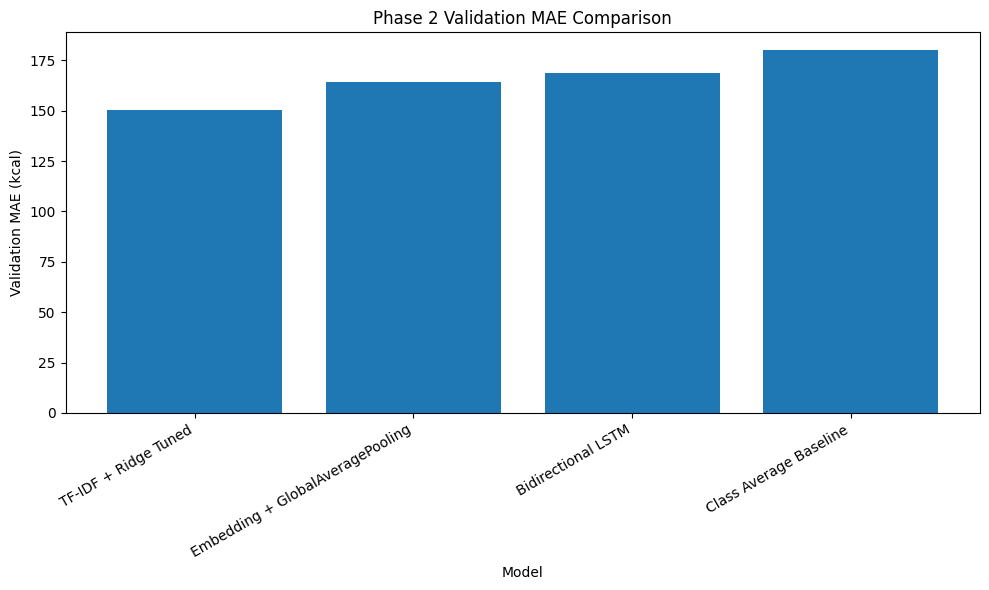

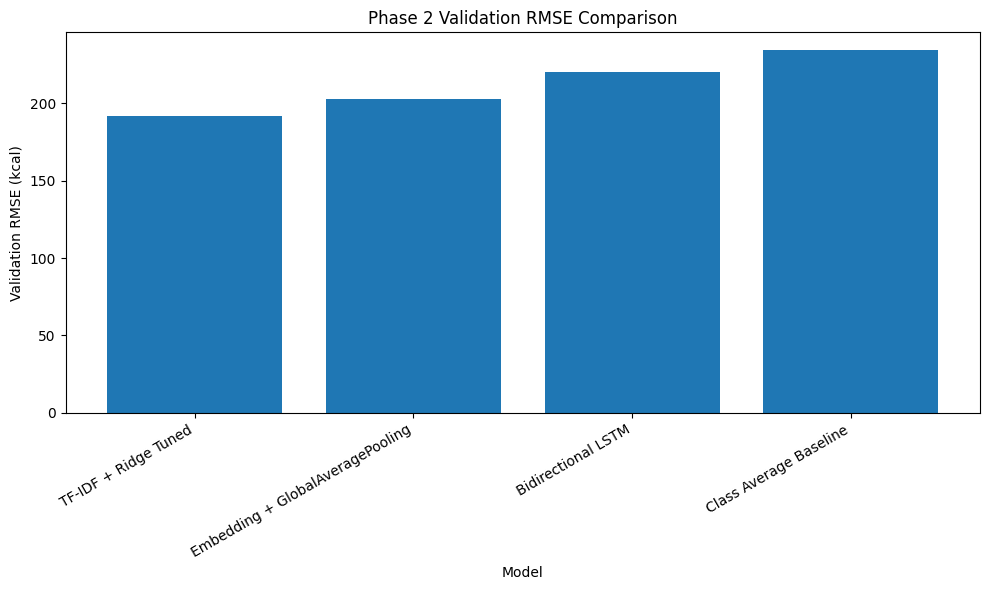

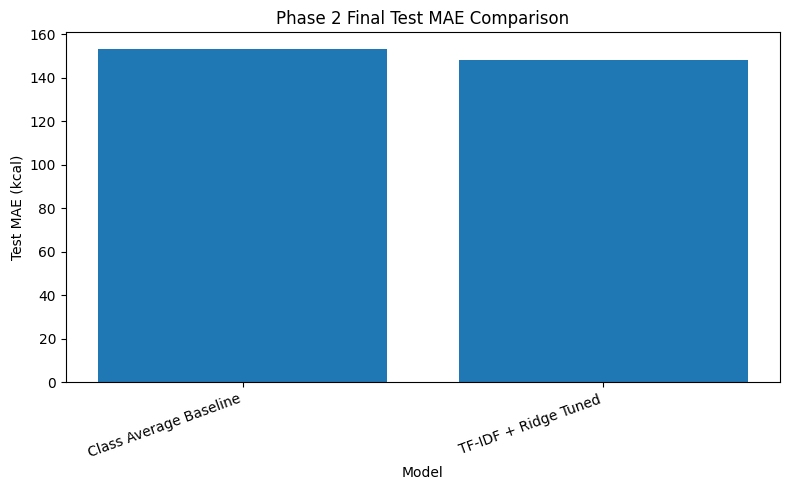

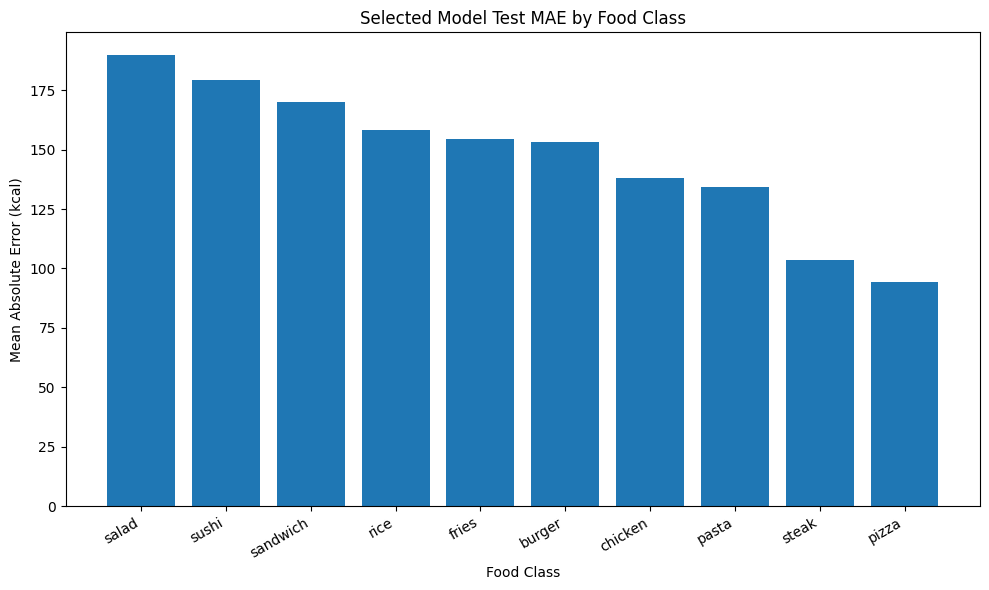

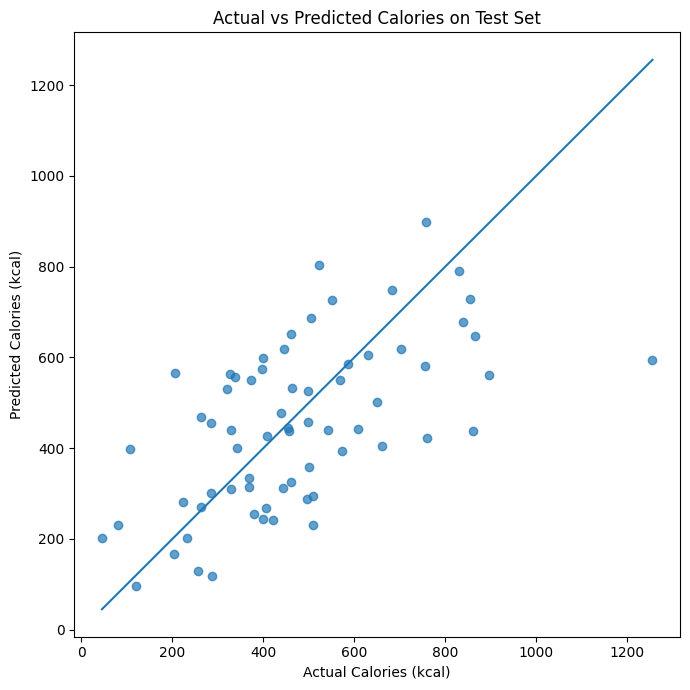

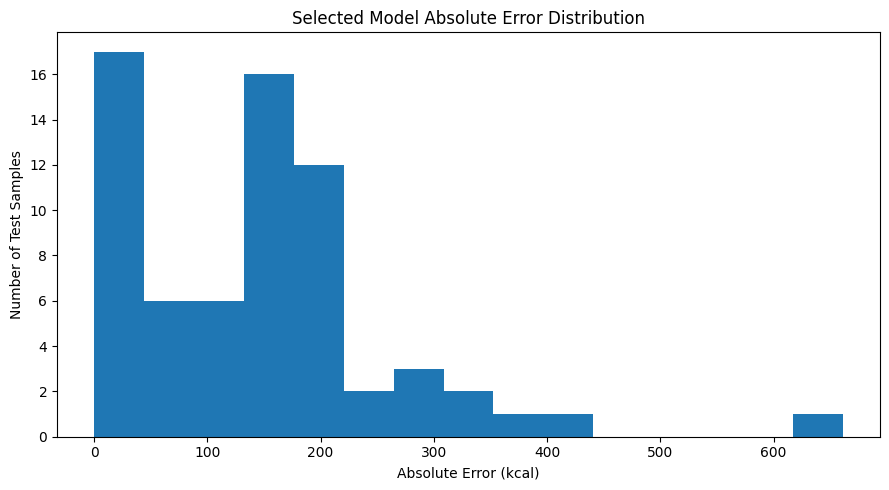

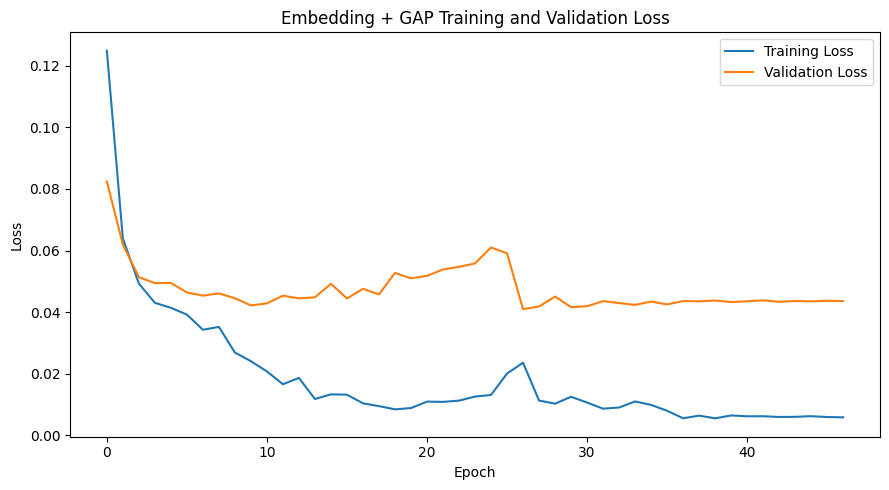

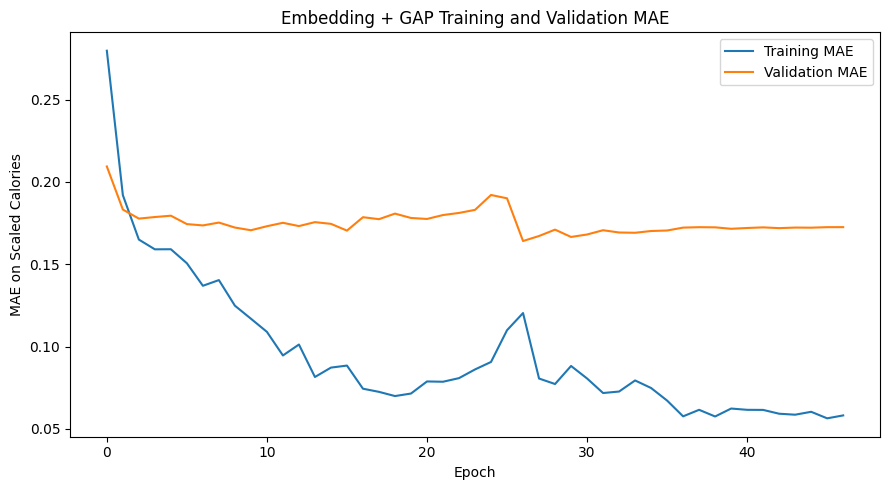

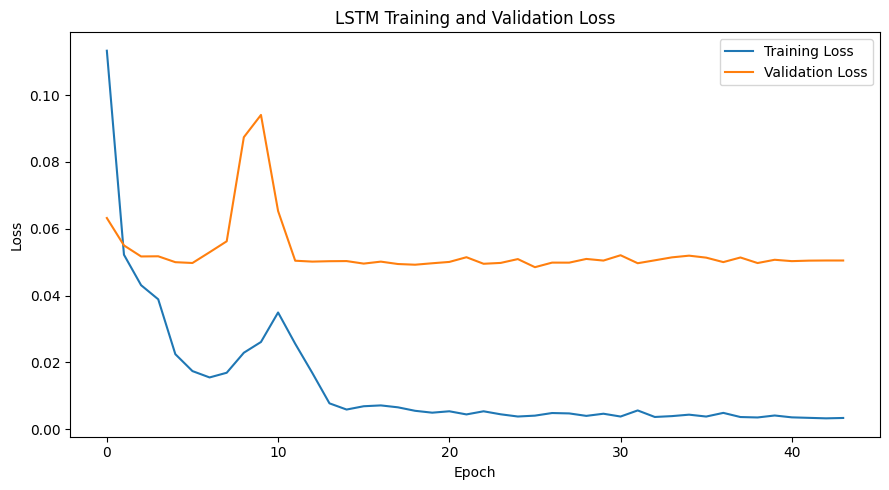

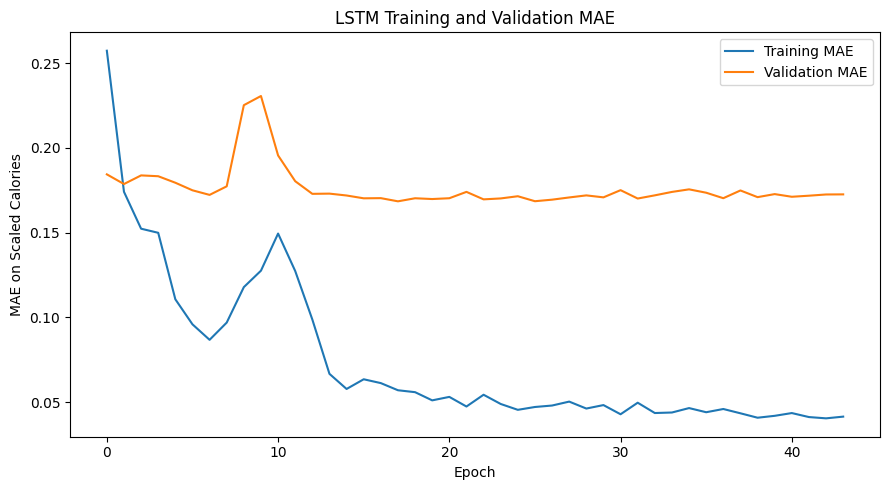


Phase 2 visualizations saved successfully.

Visualization folder:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations

Visualization index saved to:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_visualization_index.csv

Saved visualization files:
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_validation_mae_comparison.png
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_validation_rmse_comparison.png
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_test_mae_comparison.png
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_test_mae_by_food_class.png
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_actual_vs_predicted_calories.png
/content/drive/MyDrive/Calorify/phase2_text_calorie/results/visualizations/phase2_absolute_error_distribution.png
/content/drive/MyDrive/C

In [ ]:
# Cell 11 — Phase 2 visualizations for report and presentation

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PHASE2_DIR = Path("/content/drive/MyDrive/Calorify/phase2_text_calorie")
RESULTS_DIR = PHASE2_DIR / "results"
VIS_DIR = RESULTS_DIR / "visualizations"

VIS_DIR.mkdir(parents=True, exist_ok=True)

validation_comparison_path = RESULTS_DIR / "phase2_validation_model_comparison.csv"
final_test_summary_path = RESULTS_DIR / "phase2_final_test_summary.csv"
test_predictions_path = RESULTS_DIR / "tfidf_ridge_best_test_predictions.csv"
test_mae_by_class_path = RESULTS_DIR / "tfidf_ridge_best_test_mae_by_class.csv"
embedding_history_path = RESULTS_DIR / "embedding_gap_training_history.csv"
lstm_history_path = RESULTS_DIR / "lstm_training_history.csv"

validation_comparison_df = pd.read_csv(validation_comparison_path)
final_test_summary_df = pd.read_csv(final_test_summary_path)
test_predictions_df = pd.read_csv(test_predictions_path)
test_mae_by_class_df = pd.read_csv(test_mae_by_class_path)

embedding_history_df = pd.read_csv(embedding_history_path)
lstm_history_df = pd.read_csv(lstm_history_path)

print("Loaded Phase 2 result files successfully.")

print("\nValidation comparison:")
display(validation_comparison_df)

print("\nFinal test summary:")
display(final_test_summary_df)

print("\nTest MAE by class:")
display(test_mae_by_class_df)

# 1. Validation MAE comparison
plt.figure(figsize=(10, 6))
plt.bar(validation_comparison_df["model_name"], validation_comparison_df["validation_mae"])
plt.title("Phase 2 Validation MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Validation MAE (kcal)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

validation_mae_plot_path = VIS_DIR / "phase2_validation_mae_comparison.png"
plt.savefig(validation_mae_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 2. Validation RMSE comparison
plt.figure(figsize=(10, 6))
plt.bar(validation_comparison_df["model_name"], validation_comparison_df["validation_rmse"])
plt.title("Phase 2 Validation RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("Validation RMSE (kcal)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

validation_rmse_plot_path = VIS_DIR / "phase2_validation_rmse_comparison.png"
plt.savefig(validation_rmse_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 3. Final test MAE comparison
plt.figure(figsize=(8, 5))
plt.bar(final_test_summary_df["model_name"], final_test_summary_df["test_mae"])
plt.title("Phase 2 Final Test MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Test MAE (kcal)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

test_mae_plot_path = VIS_DIR / "phase2_test_mae_comparison.png"
plt.savefig(test_mae_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 4. Selected model test MAE by food class
test_mae_by_class_sorted_df = test_mae_by_class_df.sort_values("mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(test_mae_by_class_sorted_df["food_class"], test_mae_by_class_sorted_df["mean"])
plt.title("Selected Model Test MAE by Food Class")
plt.xlabel("Food Class")
plt.ylabel("Mean Absolute Error (kcal)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

test_mae_by_class_plot_path = VIS_DIR / "phase2_test_mae_by_food_class.png"
plt.savefig(test_mae_by_class_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 5. Actual vs predicted calories scatter plot
actual_calories = test_predictions_df["calories"].astype(float)
predicted_calories = test_predictions_df["predicted_calories"].astype(float)

min_value = min(actual_calories.min(), predicted_calories.min())
max_value = max(actual_calories.max(), predicted_calories.max())

plt.figure(figsize=(7, 7))
plt.scatter(actual_calories, predicted_calories, alpha=0.7)
plt.plot([min_value, max_value], [min_value, max_value])
plt.title("Actual vs Predicted Calories on Test Set")
plt.xlabel("Actual Calories (kcal)")
plt.ylabel("Predicted Calories (kcal)")
plt.tight_layout()

actual_vs_predicted_plot_path = VIS_DIR / "phase2_actual_vs_predicted_calories.png"
plt.savefig(actual_vs_predicted_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 6. Absolute error distribution
plt.figure(figsize=(9, 5))
plt.hist(test_predictions_df["absolute_error"], bins=15)
plt.title("Selected Model Absolute Error Distribution")
plt.xlabel("Absolute Error (kcal)")
plt.ylabel("Number of Test Samples")
plt.tight_layout()

error_distribution_plot_path = VIS_DIR / "phase2_absolute_error_distribution.png"
plt.savefig(error_distribution_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 7. Embedding + GAP training curves
plt.figure(figsize=(9, 5))
plt.plot(embedding_history_df["loss"], label="Training Loss")
plt.plot(embedding_history_df["val_loss"], label="Validation Loss")
plt.title("Embedding + GAP Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

embedding_loss_plot_path = VIS_DIR / "embedding_gap_loss_curve.png"
plt.savefig(embedding_loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(embedding_history_df["mae"], label="Training MAE")
plt.plot(embedding_history_df["val_mae"], label="Validation MAE")
plt.title("Embedding + GAP Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE on Scaled Calories")
plt.legend()
plt.tight_layout()

embedding_mae_plot_path = VIS_DIR / "embedding_gap_mae_curve.png"
plt.savefig(embedding_mae_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# 8. LSTM training curves
plt.figure(figsize=(9, 5))
plt.plot(lstm_history_df["loss"], label="Training Loss")
plt.plot(lstm_history_df["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

lstm_loss_plot_path = VIS_DIR / "lstm_loss_curve.png"
plt.savefig(lstm_loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(lstm_history_df["mae"], label="Training MAE")
plt.plot(lstm_history_df["val_mae"], label="Validation MAE")
plt.title("LSTM Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE on Scaled Calories")
plt.legend()
plt.tight_layout()

lstm_mae_plot_path = VIS_DIR / "lstm_mae_curve.png"
plt.savefig(lstm_mae_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# Save visualization index
visualization_files = [
    validation_mae_plot_path,
    validation_rmse_plot_path,
    test_mae_plot_path,
    test_mae_by_class_plot_path,
    actual_vs_predicted_plot_path,
    error_distribution_plot_path,
    embedding_loss_plot_path,
    embedding_mae_plot_path,
    lstm_loss_plot_path,
    lstm_mae_plot_path
]

visualization_index_df = pd.DataFrame({
    "visualization_name": [path.stem for path in visualization_files],
    "file_path": [str(path) for path in visualization_files]
})

visualization_index_path = VIS_DIR / "phase2_visualization_index.csv"
visualization_index_df.to_csv(visualization_index_path, index=False)

print("\nPhase 2 visualizations saved successfully.")
print("\nVisualization folder:")
print(VIS_DIR)

print("\nVisualization index saved to:")
print(visualization_index_path)

print("\nSaved visualization files:")
for path in visualization_files:
    print(path)

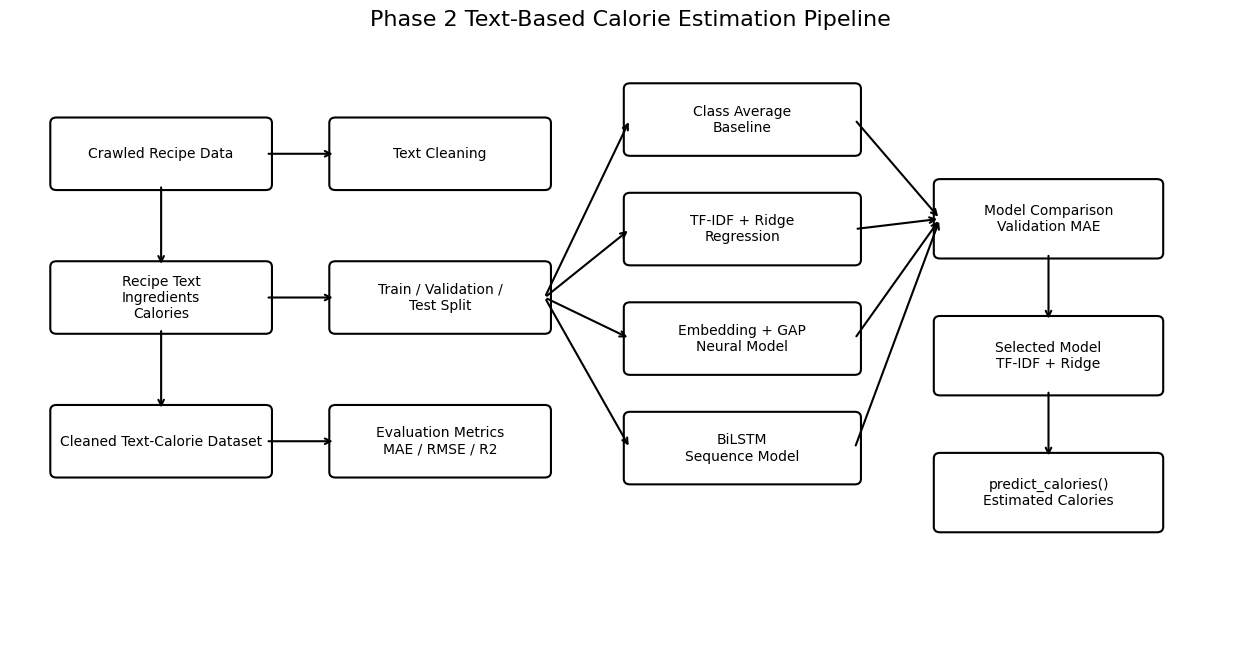

Saved to: /content/drive/MyDrive/Calorify/phase2_text_calorie/screenshots/phase2_text_calorie_pipeline_diagram.png


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

PROJECT_ROOT = Path("/content/drive/MyDrive/Calorify")
PHASE2_ROOT = PROJECT_ROOT / "phase2_text_calorie"
SCREENSHOTS_DIR = PHASE2_ROOT / "screenshots"

SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

def draw_box(x, y, width, height, text):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True
    )

def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

draw_box(0.6, 6.8, 2.7, 0.9, "Crawled Recipe Data")
draw_box(0.6, 4.7, 2.7, 0.9, "Recipe Text\nIngredients\nCalories")
draw_box(0.6, 2.6, 2.7, 0.9, "Cleaned Text-Calorie Dataset")

draw_box(4.2, 6.8, 2.7, 0.9, "Text Cleaning")
draw_box(4.2, 4.7, 2.7, 0.9, "Train / Validation /\nTest Split")
draw_box(4.2, 2.6, 2.7, 0.9, "Evaluation Metrics\nMAE / RMSE / R2")

draw_box(8.0, 7.3, 2.9, 0.9, "Class Average\nBaseline")
draw_box(8.0, 5.7, 2.9, 0.9, "TF-IDF + Ridge\nRegression")
draw_box(8.0, 4.1, 2.9, 0.9, "Embedding + GAP\nNeural Model")
draw_box(8.0, 2.5, 2.9, 0.9, "BiLSTM\nSequence Model")

draw_box(12.0, 5.8, 2.8, 1.0, "Model Comparison\nValidation MAE")
draw_box(12.0, 3.8, 2.8, 1.0, "Selected Model\nTF-IDF + Ridge")
draw_box(12.0, 1.8, 2.8, 1.0, "predict_calories()\nEstimated Calories")

draw_arrow(1.95, 6.8, 1.95, 5.6)
draw_arrow(1.95, 4.7, 1.95, 3.5)

draw_arrow(3.3, 7.25, 4.2, 7.25)
draw_arrow(3.3, 5.15, 4.2, 5.15)
draw_arrow(3.3, 3.05, 4.2, 3.05)

draw_arrow(6.9, 5.15, 8.0, 7.75)
draw_arrow(6.9, 5.15, 8.0, 6.15)
draw_arrow(6.9, 5.15, 8.0, 4.55)
draw_arrow(6.9, 5.15, 8.0, 2.95)

draw_arrow(10.9, 7.75, 12.0, 6.3)
draw_arrow(10.9, 6.15, 12.0, 6.3)
draw_arrow(10.9, 4.55, 12.0, 6.3)
draw_arrow(10.9, 2.95, 12.0, 6.3)

draw_arrow(13.4, 5.8, 13.4, 4.8)
draw_arrow(13.4, 3.8, 13.4, 2.8)

plt.title("Phase 2 Text-Based Calorie Estimation Pipeline", fontsize=16)

phase2_pipeline_diagram_path = SCREENSHOTS_DIR / "phase2_text_calorie_pipeline_diagram.png"
plt.savefig(phase2_pipeline_diagram_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved to:", phase2_pipeline_diagram_path)